# Bank Marketing — Customer Segmentation with K-Prototypes

## Objective
This notebook segments bank customers using **K-Prototypes clustering** to identify high-propensity groups likely to subscribe to a term deposit.

Unlike K-Means (numeric only) or K-Modes (categorical only), **K-Prototypes handles mixed-type data natively** — making it ideal for the UCI Bank Marketing dataset which contains both numeric and categorical features.

## Workflow
```
1. Load raw data
2. Define numeric & categorical features
3. Scale numeric features (StandardScaler)
4. Find optimal k using Elbow Method
5. Fit final K-Prototypes model
6. Interpret: conversion rate per cluster
7. Profile each cluster (mean + mode)
8. Visualize with heatmap
9. Name segments & export results
```

# 1. Installing Required Library and Importing this

In [7]:
#!pip install kmodes

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 2. Dataset Loading

In [9]:
df = pd.read_csv('/kaggle/input/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset/bank-additional-full.csv', sep=';') #Use the Raw data (in this case we use kaggle original data)

In [10]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# 3. Defining Feature Types

In [11]:
num_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

cat_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month',
    'day_of_week', 'poutcome'
]

# Encode target: yes=1, no=0
target = df['y'].map({'yes': 1, 'no': 0})

# Build feature matrix (numerics first, then categoricals)
X = df[num_cols + cat_cols].copy()

# Get categorical column indices — K-Prototypes needs these!
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

print(f'Numeric features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Categorical indices in X: {cat_idx}')

Numeric features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Categorical indices in X: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


# 4. Scalling Numeric Features

In [12]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

print('Numeric features scaled to mean=0, std=1')
print(X_scaled[num_cols].describe().loc[['mean','std']].round(3))

Numeric features scaled to mean=0, std=1
      age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
mean -0.0      -0.0      -0.0   -0.0       0.0          -0.0            -0.0   
std   1.0       1.0       1.0    1.0       1.0           1.0             1.0   

      cons.conf.idx  euribor3m  nr.employed  
mean           -0.0       -0.0          0.0  
std             1.0        1.0          1.0  


# 5. Finding Optimal k with Elbow Method

Fitting k=2... cost=362920.96
Fitting k=3... cost=311496.52
Fitting k=4... cost=289219.69
Fitting k=5... cost=268031.26
Fitting k=6... cost=254788.22
Fitting k=7... cost=235852.02
Fitting k=8... cost=221883.85


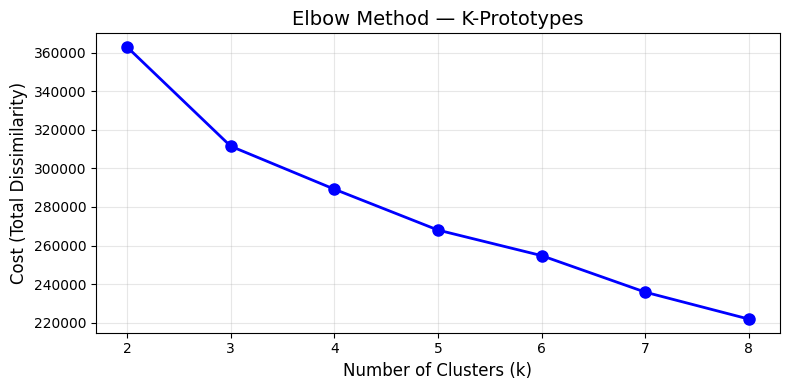

In [13]:
costs = []
k_range = range(2, 9)

for k in k_range:
    print(f'Fitting k={k}...', end=' ')
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
    kproto.fit(X_scaled, categorical=cat_idx)
    costs.append(kproto.cost_)
    print(f'cost={kproto.cost_:.2f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), costs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Cost (Total Dissimilarity)', fontsize=12)
plt.title('Elbow Method — K-Prototypes', fontsize=14)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The cost drops very sharply from 2 → 3, still noticeably from 3 → 4, and after that the improvement becomes more gradual. That pattern usually suggests the “elbow” is around 3 or 4, not at higher values.

# 6. Fit Final K-Prototypes Model

In [15]:
k_optimal = 4

print(f'Fitting final model with k={k_optimal}...')
kproto_final = KPrototypes(n_clusters=k_optimal, init='Cao', random_state=42, n_jobs=-1)
clusters = kproto_final.fit_predict(X_scaled, categorical=cat_idx)

df_result = df[num_cols + cat_cols].copy()
df_result['cluster'] = clusters
df_result['y'] = target

print(f'\nCluster size distribution:')
print(df_result['cluster'].value_counts().sort_index())

Fitting final model with k=4...

Cluster size distribution:
cluster
0     1693
1    11992
2    25963
3     1540
Name: count, dtype: int64


# 7. Conversion Rate per Cluster

In [17]:
conversion = df_result.groupby('cluster')['y'].agg(
    conversion_rate='mean',
    cluster_size='count'
).reset_index()
conversion['conversion_rate_pct'] = (conversion['conversion_rate'] * 100).round(1)
conversion['share_of_total'] = (conversion['cluster_size'] / len(df_result) * 100).round(1)
conversion = conversion.sort_values('conversion_rate_pct', ascending=False)

print('=== Conversion Rate by Cluster ===')
print(conversion[['cluster','conversion_rate_pct','cluster_size','share_of_total']].to_string(index=False))
print(f'\nBaseline (overall): {target.mean()*100:.1f}%')

=== Conversion Rate by Cluster ===
 cluster  conversion_rate_pct  cluster_size  share_of_total
       3                 63.2          1540             3.7
       1                 19.4         11992            29.1
       2                  4.9         25963            63.0
       0                  3.4          1693             4.1

Baseline (overall): 11.3%


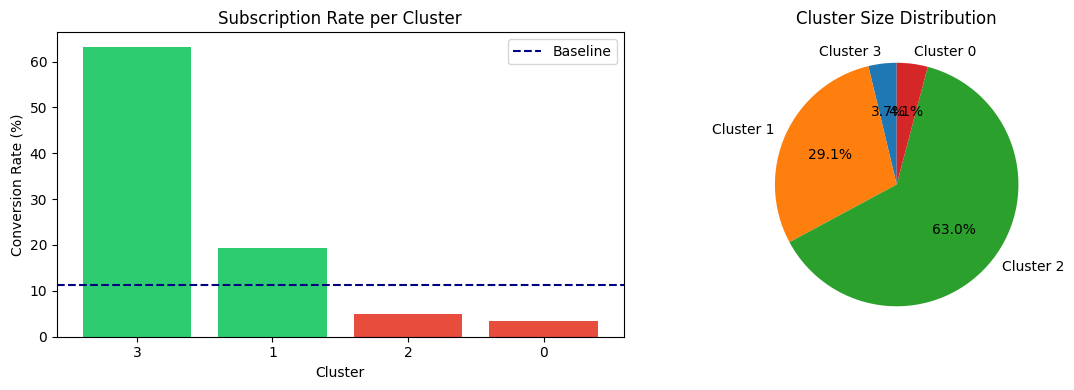

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(conversion['cluster'].astype(str), conversion['conversion_rate_pct'],
            color=['#2ecc71' if r > target.mean()*100 else '#e74c3c'
                   for r in conversion['conversion_rate_pct']])
axes[0].axhline(y=target.mean()*100, color='navy', linestyle='--', label='Baseline')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Subscription Rate per Cluster')
axes[0].legend()

axes[1].pie(conversion['cluster_size'], labels=[f'Cluster {c}' for c in conversion['cluster']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Cluster Size Distribution')

plt.tight_layout()
plt.show()

# 8. Profilling Each User

In [19]:
# Numeric profile — use original unscaled values for readability
num_profile = df_result.groupby('cluster')[num_cols].mean().round(2)

# Categorical profile — use mode (most frequent value)
cat_profile = df_result.groupby('cluster')[cat_cols].agg(
    lambda x: x.value_counts().index[0]
)

full_profile = pd.concat([num_profile, cat_profile], axis=1)

print('=== Full Cluster Profile (numeric=mean, categorical=mode) ===')
print(full_profile.T.to_string())

=== Full Cluster Profile (numeric=mean, categorical=mode) ===
cluster                         0                  1                  2                  3
age                         40.51              39.39              40.17              41.91
duration                   174.58             263.73             257.43             322.33
campaign                    12.43               2.11               2.18               1.83
pdays                       999.0              999.0              999.0              22.13
previous                      0.0               0.32               0.03               1.69
emp.var.rate                  1.3              -2.03                1.1              -2.09
cons.price.idx              93.97              92.99              93.84              93.35
cons.conf.idx              -40.07             -43.19             -39.42             -38.33
euribor3m                     4.9                1.2               4.81               0.98
nr.employed               52

# 9. Heatmap of Numeric Profile

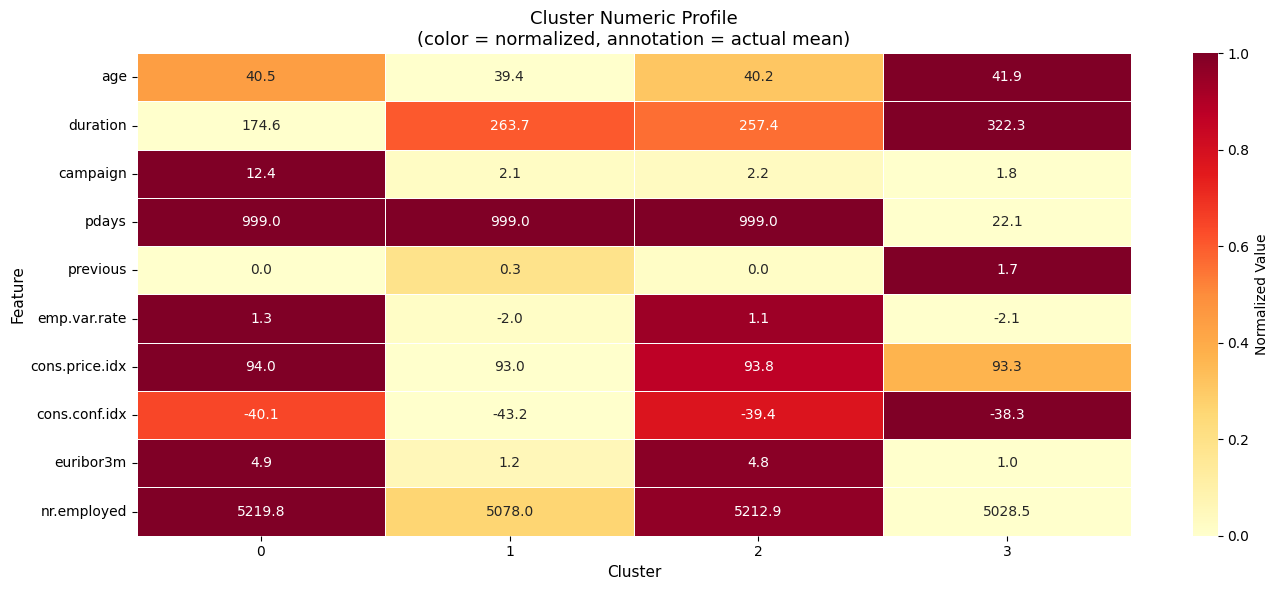

In [20]:
num_profile_norm = (num_profile - num_profile.min()) / (num_profile.max() - num_profile.min())

plt.figure(figsize=(14, 6))
sns.heatmap(
    num_profile_norm.T,
    annot=num_profile.T,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Value'}
)
plt.title('Cluster Numeric Profile\n(color = normalized, annotation = actual mean)', fontsize=13)
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

# 10. Segmenting

In [21]:
segment_names = {
    0: 'Cluster 0 — Resistant Non-Responders',
    1: 'Cluster 1 — Promising Prospects',
    2: 'Cluster 2 — Unengaged Majority',
    3: 'Cluster 3 — Loyal Responders',
}

df_result['segment'] = df_result['cluster'].map(segment_names)

# Final summary
summary = df_result.groupby('segment').agg(
    size=('y', 'count'),
    conversion_rate=('y', lambda x: f"{x.mean()*100:.1f}%")
).reset_index()
print('=== Final Segment Summary ===')
print(summary.to_string(index=False))

=== Final Segment Summary ===
                             segment  size conversion_rate
Cluster 0 — Resistant Non-Responders  1693            3.4%
     Cluster 1 — Promising Prospects 11992           19.4%
      Cluster 2 — Unengaged Majority 25963            4.9%
        Cluster 3 — Loyal Responders  1540           63.2%


# 11. Summary & Business Recommendation

## **Summary**

- K-Prototypes identified 4 distinct customer segments in the UCI Bank Marketing dataset.
- Cluster 3 (Loyal Responders) is characterized by customers with previous successful campaign outcomes, longer call durations, and favorable economic conditions. This segment achieved the highest subscription rate of 63.2%, substantially exceeding the overall campaign baseline of approximately 11%.
- Cluster 1 (Promising Prospects) consists of customers contacted mainly through cellular channels with moderate engagement and a subscription rate of 19.4%, which is also above the campaign average.
- Cluster 2 (Unengaged Majority) represents the largest segment (63% of customers) but exhibits a relatively low subscription rate of 4.9%.
- Cluster 0 (Resistant Non-Responders) shows the lowest subscription rate (3.4%) despite receiving the highest number of campaign contacts, suggesting diminishing returns from repeated outreach.

## **Business Recommendations**
1. Prioritize Cluster 3 (Loyal Responders)
- This segment demonstrates the highest likelihood of subscription and delivers the greatest return on marketing investment.
- The bank should allocate more campaign resources toward customers with characteristics similar to this cluster.
- Personalized offers and relationship-based marketing strategies are likely to achieve high conversion rates.

2. Actively Target Cluster 1 (Promising Prospects)
- Although conversion rates are lower than Cluster 3, they remain significantly above the overall average.
- Additional follow-up calls, tailored product recommendations, and targeted promotions could further improve conversion performance.
- This segment represents an attractive growth opportunity due to its relatively large size (29.1% of customers).

3. Optimize Marketing Efforts for Cluster 2 (Unengaged Majority)
- As the largest segment, even small improvements in conversion could generate substantial business value.
- Rather than increasing call frequency, the bank should experiment with alternative communication strategies, customer education, or more personalized messaging.
- Marketing budgets should be carefully managed to avoid excessive spending on low-probability customers.

4. Reduce Resources Allocated to Cluster 0 (Resistant Non-Responders)
- This segment has already received numerous campaign contacts yet continues to show very low conversion rates.
- Further telemarketing efforts are unlikely to be cost-effective.
- The bank should either deprioritize this segment or engage them through lower-cost digital marketing channels.


## **Conclusion**

The clustering analysis reveals that customer responsiveness varies substantially across segments. The most effective strategy is to prioritize ***Loyal Responders (Cluster 3)*** and ***Promising Prospects (Cluster 1)***, while applying cost-efficient and alternative engagement approaches to ***Unengaged Majority (Cluster 2)*** and ***Resistant Non-Responders (Cluster 0)***. This segmentation-driven approach can improve marketing efficiency, increase subscription rates, and maximize campaign ROI.